In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi']=100

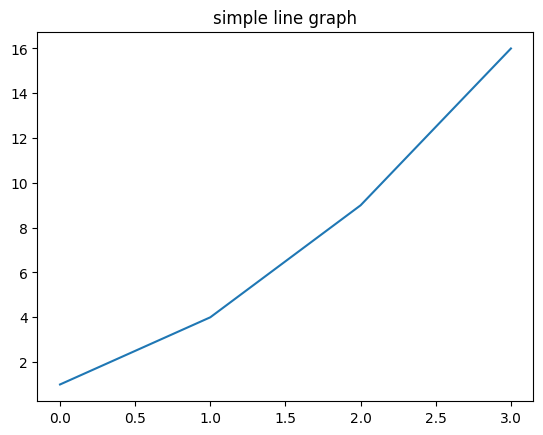

In [ ]:
plt.plot([1,4,9,16])
plt.title('simple line graph')
plt.show()

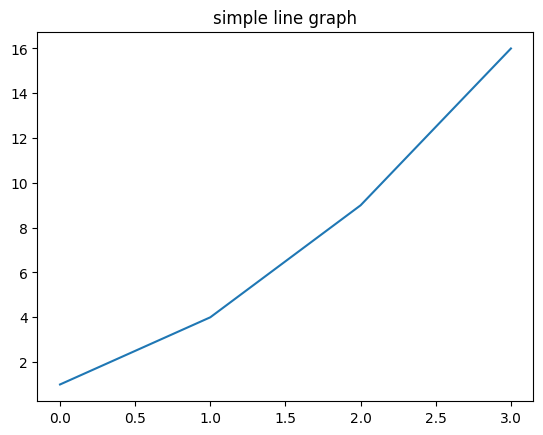

In [ ]:
fig,ax=plt.subplots()
ax.plot([1,4,9,16])
ax.set_title('simple line graph')
plt.show()

In [ ]:
import gdown
gdown.download('https://bit.ly/3pK7iuu','ns_book7.csv',quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 133MB/s]


'ns_book7.csv'

In [ ]:
import pandas as pd

ns_book7=pd.read_csv('ns_book7.csv')
ns_book7.head()

/tmp/ipykernel_1134/1586689114.py:3: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  ns_book7=pd.read_csv('ns_book7.csv')


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [ ]:
top_30_pubs=ns_book7['출판사'].value_counts()[:30]
top_30_pubs

,count
출판사,
문학동네,4410
민음사,3349
김영사,3246
웅진씽크빅,3227
시공사,2685
창비,2469
문학과지성사,2064
위즈덤하우스,1981
학지사,1877


In [ ]:
top_30_pubs_idx=ns_book7['출판사'].isin(top_30_pubs.index)
top_30_pubs_idx.sum()

np.int64(51886)

In [ ]:
ns_book8=ns_book7[top_30_pubs_idx].sample(1000,random_state=42)
ns_book8.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
141760,155786,제갈량 문집,제갈량 지음 ;조영래 옮김,지식을만드는지식,2012,9788966805785,NaN,0,10,808,1,2,2013-04-10
249855,268595,존 레넌을 찾아서,토니 파슨스 지음;이은정 옮김,시공사,2007,9788952750419,NaN,0,NaN,843,1,18,2007-12-14
129347,142802,요리사 & 쇼핑호스트 :생활과학 계열·예체능 계열,와이즈멘토 글 ;김성희 그림,김영사,2013,9788934959854,9788934959717,7,14,321.55,1,3,2013-12-09
349194,371975,임정섭의 글쓰기 훈련소,임정섭 지음,다산북스,2017,9791130614472,NaN,NaN,NaN,NaN,1,0,1970-01-01
46734,51748,초한지 :이문열의 史記 이야기,지은이: 이문열,민음사,2017,9788937481659,9788937481581,0,7,813.6,1,9,2018-07-02


/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) mi

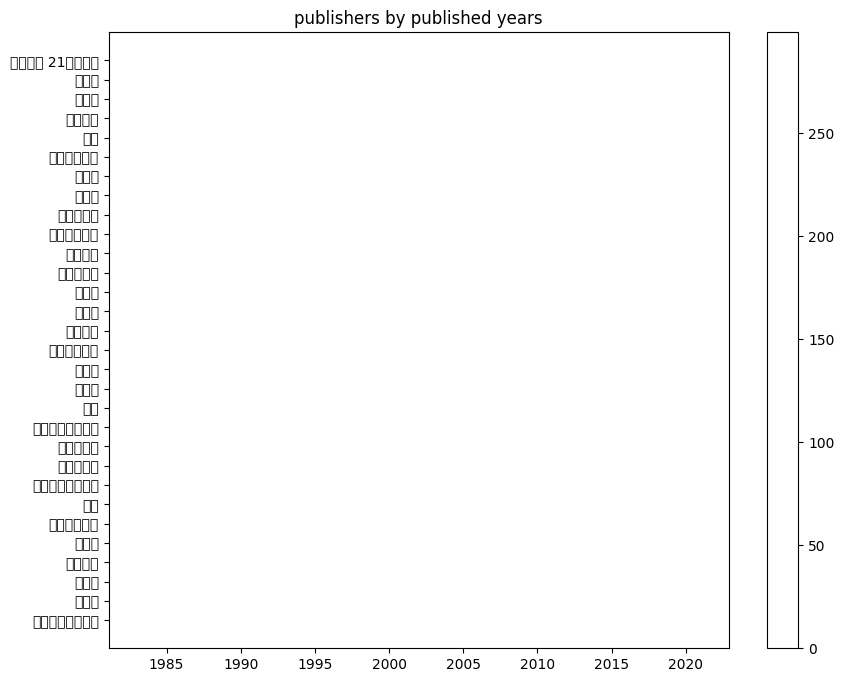

In [ ]:
fig, ax= plt.subplots(figsize=(10,8))
sc=ax.scatter(ns_book8['발행년도'],ns_book8['출판사'],
           linewidths=0.5, edgecolors='k',alpha=0,
           s=ns_book8['대출건수']*2,c=ns_book8['대출건수'])
#s=마커의 크기(size),c=마커의 컬러(해당 데이터의 수에 따라 달라짐), edgecolor=마커 테두리 색
#linewidths=테두리 선 두꼐
ax.set_title('publishers by published years')
fig.colorbar(sc)#sc의 컬러바 보여줌
fig.show()

In [ ]:
top_30_pubs=ns_book7.groupby('출판사')['대출건수'].sum().sort_values(ascending=False)[:30]
top_30_pubs

,대출건수
출판사,
문학동네,88736
웅진씽크빅,77547
김영사,73851
민음사,54928
시공사,50373
위즈덤하우스,42252
랜덤하우스코리아,41238
자음과모음,33472
창비,32293


In [ ]:
top_30_pubs_idx=ns_book7['출판사'].isin(top_30_pubs.index)

In [ ]:
ns_book9=ns_book7[top_30_pubs_idx][['출판사','발행년도','대출건수']]
ns_book9.groupby(['출판사','발행년도'])['대출건수'].sum()

출판사   발행년도
길벗    1994     30
      1995     18
      1996     21
      1997      2
      1998      8
             ... 
황금가지  2018    200
      2019    133
      2020     98
      2021      1
      2030      2
Name: 대출건수, Length: 867, dtype: int64

In [ ]:
#ns_book9=ns_book9.reset_index()
ns_book9=ns_book9.sort_values(by='발행년도')
ns_book9.head()

,출판사,발행년도,대출건수
37839,민음사,1974,1
293692,창비,1976,0
293693,문학과지성사,1977,0
38600,문학과지성사,1977,1
38696,창비,1977,0


In [ ]:
ns_book9.sort_values(by='발행년도')

,출판사,발행년도,대출건수
37839,민음사,1974,1
293692,창비,1976,0
293693,문학과지성사,1977,0
38600,문학과지성사,1977,1
38696,창비,1977,0
...,...,...,...
702,창비,2021,0
568,열린책들,2021,0
44,시공사,2021,0
24,한길사,2021,0


In [ ]:
ns_book9.reset_index()

,index,출판사,발행년도,대출건수
0,37839,민음사,1974,1
1,293692,창비,1976,0
2,293693,문학과지성사,1977,0
3,38600,문학과지성사,1977,1
4,38696,창비,1977,0
...,...,...,...,...
46303,1641,길벗,2021,2
46304,1648,한빛미디어,2021,1
46305,1434,시공사,2021,1
46306,1457,창비,2021,1


In [ ]:
line1=ns_book9[ns_book9['출판사']=='황금가지']
line2=ns_book9[ns_book9['출판사']=='비룡소']

In [ ]:
ns_book9.columns

Index(['출판사', '발행년도', '대출건수'], dtype='object')

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47329 (\N{HANGUL SYLLABLE RYONG}) 

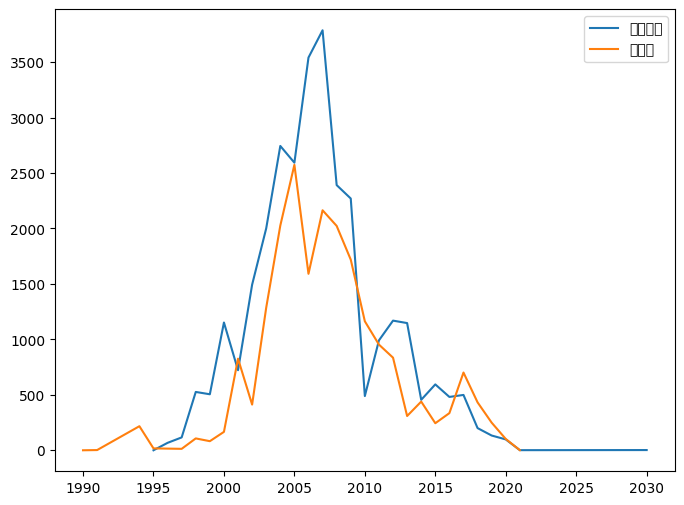

In [ ]:
line1=ns_book9[ns_book9['출판사']=='황금가지'].groupby('발행년도')['대출건수'].sum()
line2=ns_book9[ns_book9['출판사']=='비룡소'].groupby('발행년도')['대출건수'].sum()
fig, ax= plt.subplots(figsize=(8,6))
ax.plot(line1.index,line1.values,label='황금가지')#line1이 groupby때문에 series가 돼서 '발행년도'가 index 됨 '대출건수'=values
ax.plot(line2.index,line2.values,label='비룡소')

ax.legend()#범례 추가
#연도별 대출건수
fig.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50885 (\N{HANGUL SYLLABLE UNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) mi

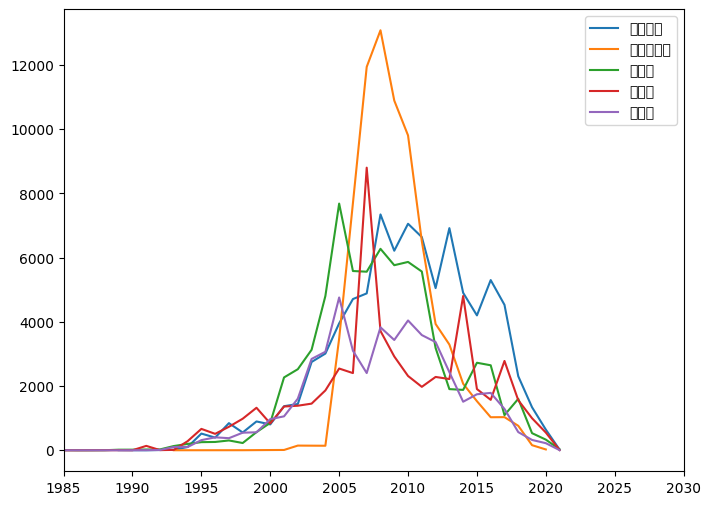

In [ ]:
fig, ax= plt.subplots(figsize=(8,6))

for idx in top_30_pubs.index[:5]:
  line1=ns_book9[ns_book9['출판사']==idx].groupby('발행년도')['대출건수'].sum()
  ax.plot(line1,label=idx)
  ax.set_xlim(1985,2030)#x축 범위 제한, set_ylim도 가능

ax.legend()#범례 추가
#연도별 대출건수
fig.show()

In [ ]:
ns_book10=ns_book9.pivot_table(index='출판사',columns='발행년도')
ns_book10.head()

대출건수                                               ...             \
발행년도 1974 1976 1977 1978 1979 1980 1981 1982 1983 1984  ...       2013   
출판사                                                     ...              
길벗    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  32.277778   
김영사   NaN  NaN  NaN  NaN  NaN  0.0  0.0  0.0  NaN  0.0  ...  13.229167   
넥서스   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  19.041667   
다락원   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  11.500000   
다산북스  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  18.333333   

                                                                       \
발행년도       2014       2015       2016       2017       2018      2019   
출판사                                                                     
길벗    25.296875  22.031250  19.962500  15.196262  11.280899  7.157407   
김영사   18.262136  28.395833  38.362319  14.025641  12.136364  4.758929   
넥서스   22.328125  16.276596  12.876404  10.964706   7.062500  4.285714   
다락원   11.210526  13.176471   6.285714   5.838710   4.384615  1.384615   
다산북스  19.442857  23.175439  16.970149  14.694118   9.662500  7.260274   

                               
발행년도      2020      2021 2030  
출판사                            
길벗    3.792208  1.000000  NaN  
김영사   3.387755  1.764706  NaN  
넥서스   1.153846  0.000000  NaN  
다락원   2.000000  0.000000  NaN  
다산북스  3.097561  2.600000  NaN  

[5 rows x 48 columns]

In [ ]:
ns_book10.columns[:80]

MultiIndex([('대출건수', 1974),
            ('대출건수', 1976),
            ('대출건수', 1977),
            ('대출건수', 1978),
            ('대출건수', 1979),
            ('대출건수', 1980),
            ('대출건수', 1981),
            ('대출건수', 1982),
            ('대출건수', 1983),
            ('대출건수', 1984),
            ('대출건수', 1985),
            ('대출건수', 1986),
            ('대출건수', 1987),
            ('대출건수', 1988),
            ('대출건수', 1989),
            ('대출건수', 1990),
            ('대출건수', 1991),
            ('대출건수', 1992),
            ('대출건수', 1993),
            ('대출건수', 1994),
            ('대출건수', 1995),
            ('대출건수', 1996),
            ('대출건수', 1997),
            ('대출건수', 1998),
            ('대출건수', 1999),
            ('대출건수', 2000),
            ('대출건수', 2001),
            ('대출건수', 2002),
            ('대출건수', 2003),
            ('대출건수', 2004),
            ('대출건수', 2005),
            ('대출건수', 2006),
            ('대출건수', 2007),
            ('대출건수', 2008),
            ('대출건수', 2009),
            ('대출건수',

In [ ]:
top_10_pubs=top_30_pubs.index[:10]
year_cols=ns_book10.columns.get_level_values(1)#pivot table에서 맨 위(0)는 index,column이라고 쓰여 있으니 두번째 층(1)을 통해 연도를 가져 옴


/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50885 (\N{HANGUL SYLLABLE UNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) mi

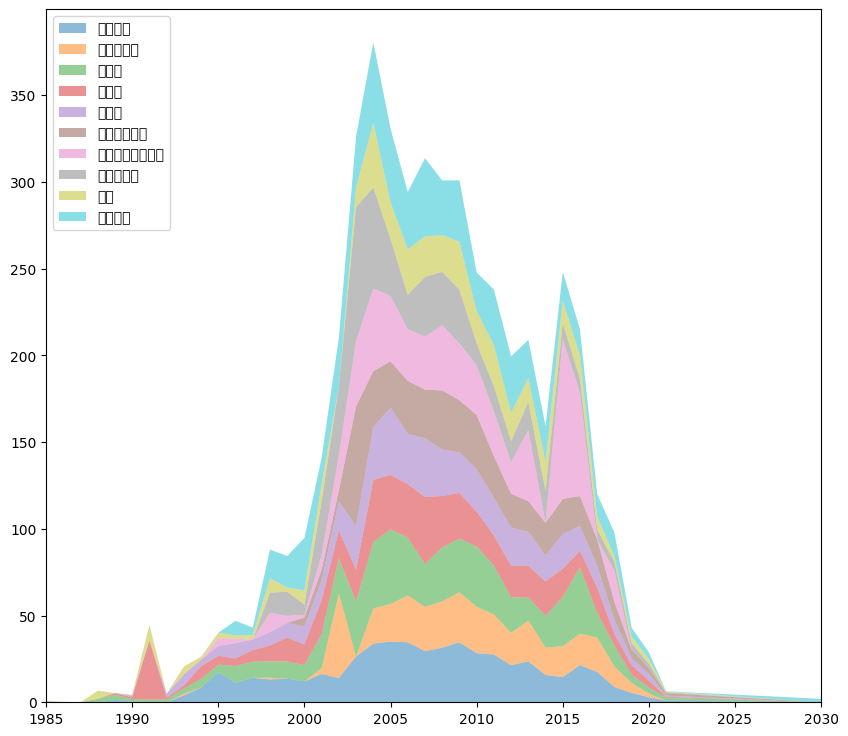

In [ ]:
fig, ax= plt.subplots(figsize=(10,9))
ax.stackplot(year_cols,ns_book10.loc[top_10_pubs].fillna(0),
             labels=top_10_pubs,alpha=0.5)#맷플롯리브는 결측치에 취약함-->fillna
ax.legend(loc='upper left')
ax.set_xlim(1985,2030)
fig.show()

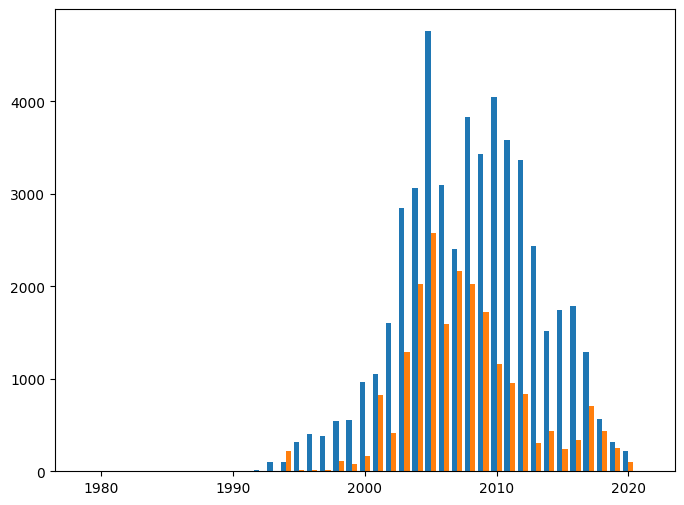

In [ ]:
fig, ax= plt.subplots(figsize=(8,6))
ax.bar(line1.index-0.2,line1.values,width=0.4)#width를 통해 막대의 폭을 지정-->+0.2,-0.2를 통해 좌우로 약간 이동
ax.bar(line2.index+0.2,line2.values,width=0.4)
fig.show()

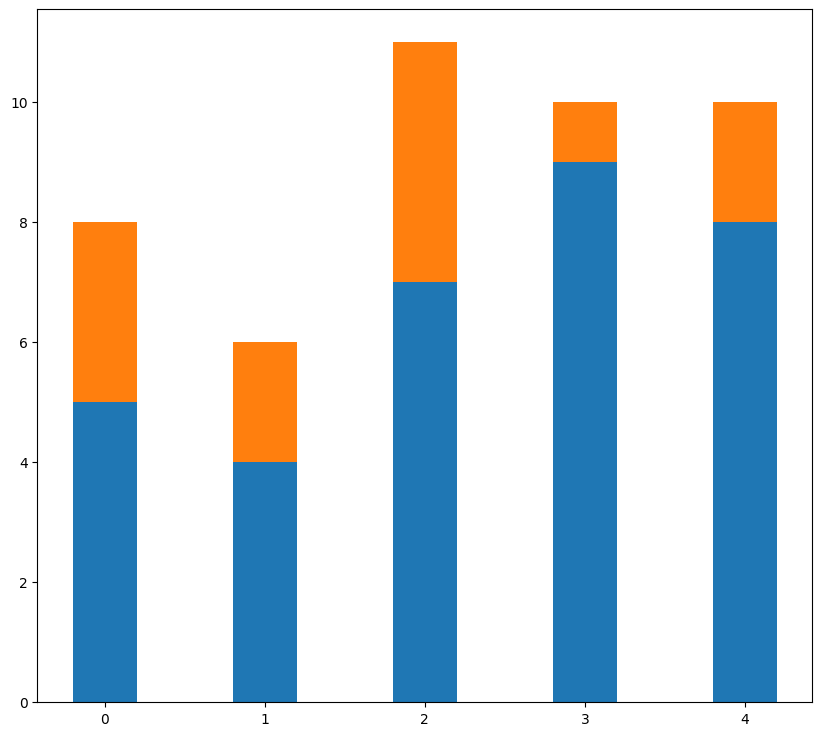

In [ ]:
#bar 그래프 누적해서 그리기
height1=[5,4,7,9,8]
height2=[3,2,4,1,2]

fig,ax=plt.subplots(figsize=(10,9))

ax.bar(range(5),height1,width=0.4)
ax.bar(range(5),height2,bottom=height1,width=0.4)
fig.show()

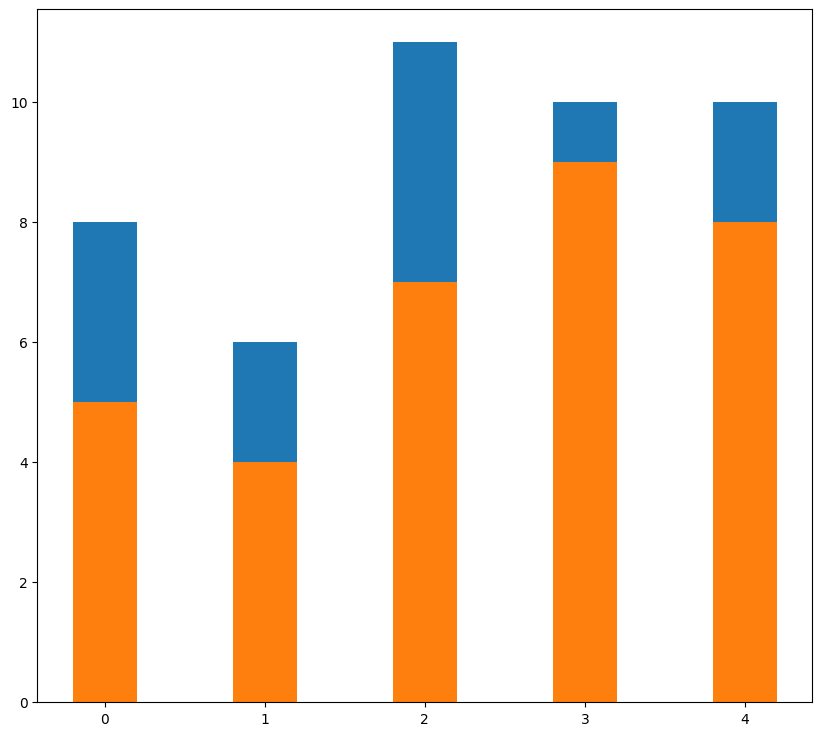

In [ ]:
#bar 그래프 누적해서 그리기
height3=[a+b for a,b in zip(height1,height2)]#미리 더해줌

fig,ax=plt.subplots(figsize=(10,9))

ax.bar(range(5),height3,width=0.4)#먼저 나온 게 더 커야 뒤에 그려지는 더 작은 값들도 보임
ax.bar(range(5),height1,width=0.4)
fig.show()

In [ ]:
ns_book10.loc[top_10_pubs[:5],('대출건수',2013):('대출건수',2020)]


대출건수                                                         \
발행년도        2013       2014       2015       2016       2017       2018   
출판사                                                                       
문학동네   23.614334  15.717949  14.536332  21.461538  17.486486   8.835249   
웅진씽크빅  23.521429  15.816794  17.779070  18.052632  19.846154  11.723077   
김영사    13.229167  18.262136  28.395833  38.362319  14.025641  12.136364   
민음사    18.338843  19.855372  16.299145   9.407186  14.797872   6.778261   
시공사    19.620968  14.970297  20.057471  14.296000  12.375000   7.971831   

                           
발행년도       2019      2020  
출판사                        
문학동네   5.403226  2.931818  
웅진씽크빅  5.678571  2.166667  
김영사    4.758929  3.387755  
민음사    5.513812  4.029197  
시공사    3.926829  3.745763

In [ ]:
#자체 누적
ns_book10.loc[top_10_pubs[:5],('대출건수',2013):('대출건수',2020)].cumsum()#axis=1방향으로 누적해줌

대출건수                                                          \
발행년도        2013       2014       2015        2016       2017       2018   
출판사                                                                        
문학동네   23.614334  15.717949  14.536332   21.461538  17.486486   8.835249   
웅진씽크빅  47.135763  31.534743  32.315402   39.514170  37.332640  20.558326   
김영사    60.364930  49.796879  60.711235   77.876489  51.358281  32.694690   
민음사    78.703773  69.652250  77.010381   87.283675  66.156154  39.472950   
시공사    98.324740  84.622547  97.067852  101.579675  78.531154  47.444781   

                             
발행년도        2019       2020  
출판사                          
문학동네    5.403226   2.931818  
웅진씽크빅  11.081797   5.098485  
김영사    15.840726   8.486240  
민음사    21.354538  12.515437  
시공사    25.281367  16.261200

In [ ]:
ns_book12=ns_book10.loc[top_10_pubs].cumsum()#loc을 써야 인덱스 슬라이싱이 됨
ns_book12

대출건수                                                     ...  \
발행년도     1974 1976 1977 1978 1979 1980 1981  1982 1983      1984  ...   
출판사                                                               ...   
문학동네      NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
웅진씽크빅     NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
김영사       NaN  NaN  NaN  NaN  NaN  0.0  0.0  0.00  NaN  0.000000  ...   
민음사       1.0  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
시공사       NaN  NaN  NaN  NaN  0.0  NaN  NaN   NaN  NaN       NaN  ...   
위즈덤하우스    NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
랜덤하우스코리아  NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
자음과모음     NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   
창비        NaN  0.0  0.0  2.0  NaN  NaN  NaN  0.25  0.0  0.142857  ...   
황금가지      NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN  NaN       NaN  ...   

                                                                      \
발행년도            2013        2014        2015        2016        2017   
출판사                                                                    
문학동네       23.614334   15.717949   14.536332   21.461538   17.486486   
웅진씽크빅      47.135763   31.534743   32.315402   39.514170   37.332640   
김영사        60.364930   49.796879   60.711235   77.876489   51.358281   
민음사        78.703773   69.652250   77.010381   87.283675   66.156154   
시공사        98.324740   84.622547   97.067852  101.579675   78.531154   
위즈덤하우스    115.940125  103.465831  117.271242  118.933657   93.796460   
랜덤하우스코리아  156.940125         NaN  209.271242  178.433657         NaN   
자음과모음     173.193856  122.126545  218.632353  186.509129   99.483960   
창비        186.874891  138.547598  231.697168  199.883362  107.160951   
황금가지      208.932583  159.229416  248.197168  214.914612  119.955823   

                                                          
발행년도           2018       2019       2020      2021 2030  
출판사                                                       
문학동네       8.835249   5.403226   2.931818  0.900000  NaN  
웅진씽크빅     20.558326  11.081797   5.098485       NaN  NaN  
김영사       32.694690  15.840726   8.486240  2.664706  NaN  
민음사       39.472950  21.354538  12.515437  3.131373  NaN  
시공사       47.444781  25.281367  16.261200  3.845658  NaN  
위즈덤하우스    57.840130  30.418772  19.770815  5.283158  NaN  
랜덤하우스코리아  75.840130        NaN        NaN       NaN  NaN  
자음과모음     80.967790  34.139702  22.033973  5.727603  NaN  
창비        84.458699  37.849847  24.968399  6.227603  NaN  
황금가지      97.792032  42.965232  28.737630  6.352603  2.0  

[10 rows x 48 columns]

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) m

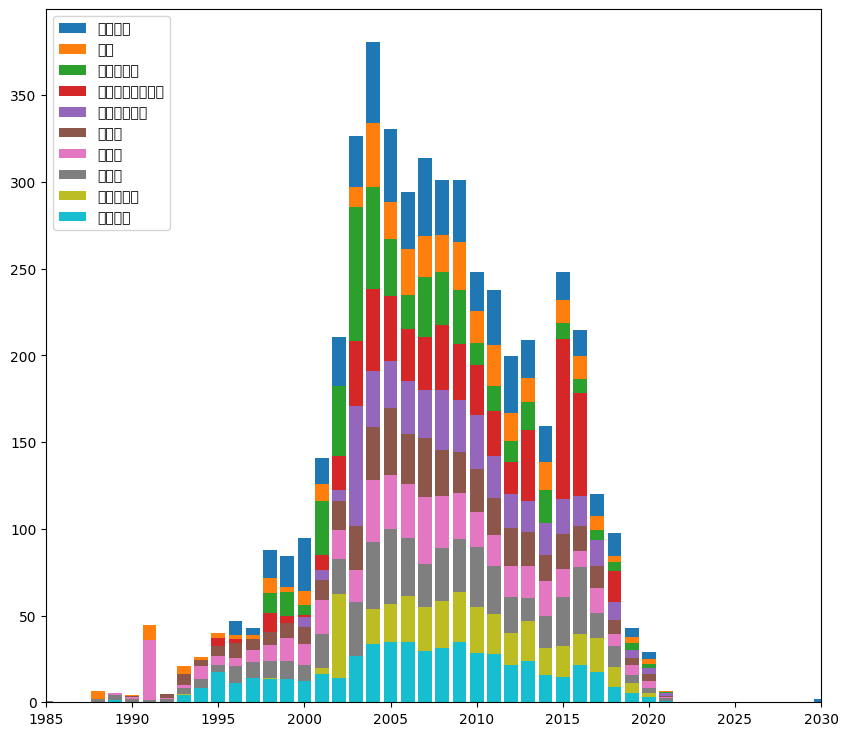

In [ ]:
fig, ax= plt.subplots(figsize=(10,9))
year_cols=ns_book12.columns.get_level_values(1)
for i in reversed(range(len(ns_book12))):
  bar=ns_book12.iloc[i]#iloc=integer location
  label=ns_book12.index[i]
  ax.bar(year_cols,bar,label=label)
ax.legend(loc='upper left')
ax.set_xlim(1985,2030)
fig.show()

In [ ]:
data=top_30_pubs[:10]
label=top_30_pubs.index[:10]

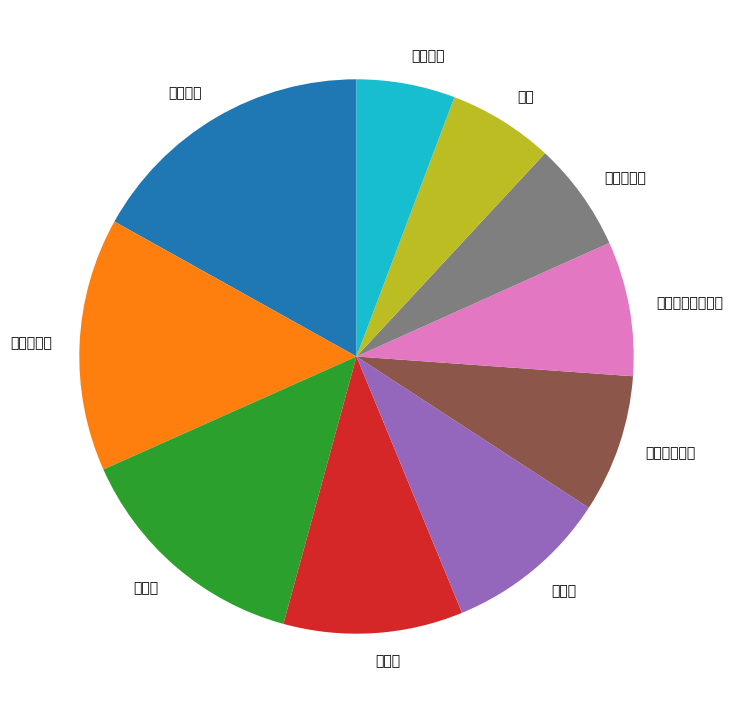

In [ ]:
#pie chart
fig,ax= plt.subplots(figsize=(10,9))
ax.pie(data,labels=label,startangle=90)#값, 해당 범주의 라벨, 시작 위치(기본=3시 방향, 90도-->12시 아마 반시계로 돌아가는 듯
fig.show()

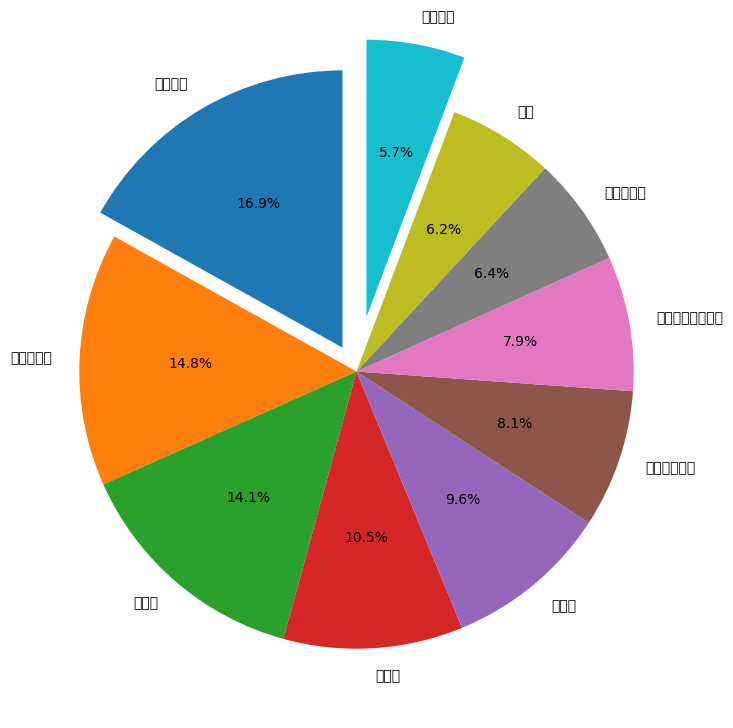

In [ ]:
fig,ax= plt.subplots(figsize=(10,9))
ax.pie(data,labels=label,startangle=90
       ,autopct='%.1f%%',explode=[0.1]+[0]*8+[0.2])
#explode-->특정 파트만 튀어나가게 해 줌(0은 가만히, 0.1은 0.1만큼 튀어나감--> 1 튀어나가게 하면 우주로 감)+[]의 총 개수는 원래 label 개수랑 같아야 함
#autopct-->percentage알려줌 .1f만큼(소수점 첫째자리)
fig.show()

In [ ]:
#pivot table
import numpy as np
ns_book11=ns_book9.pivot_table(index='출판사',columns='발행년도',values='대출건수',
                                aggfunc=np.sum,fill_value=0)
ns_book11

/tmp/ipykernel_1134/2720136975.py:3: FutureWarning: The provided callable <function sum at 0x7bf500d92a20> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ns_book11=ns_book9.pivot_table(index='출판사',columns='발행년도',values='대출건수',


발행년도,1974,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2030
출판사,,,,,,,,,,,,,,,,,,,,,
길벗,0,0,0,0,0,0,0,0,0,0,...,1162,1619,1410,1597,1626,1004,773,292,12,0
김영사,0,0,0,0,0,0,0,0,0,0,...,1905,1881,2726,2647,1094,1602,533,332,30,0
넥서스,0,0,0,0,0,0,0,0,0,0,...,1828,1429,765,1146,932,565,90,15,0,0
다락원,0,0,0,0,0,0,0,0,0,0,...,230,213,224,132,181,57,18,26,0,0
다산북스,0,0,0,0,0,0,0,0,0,0,...,1100,1361,1321,1137,1249,773,530,127,13,0
대한교과서,0,0,0,0,0,0,0,0,0,0,...,33,0,35,278,0,0,0,0,0,0
랜덤하우스코리아,0,0,0,0,0,0,0,0,0,0,...,123,0,184,119,0,18,0,0,0,0
문학과지성사,0,0,1,0,7,0,20,0,0,8,...,1285,1046,874,1155,587,471,330,151,5,0
문학동네,0,0,0,0,0,0,0,0,0,0,...,6919,4904,4201,5301,4529,2306,1340,645,18,0


In [ ]:
ns_book10.head()

대출건수                                               ...             \
발행년도 1974 1976 1977 1978 1979 1980 1981 1982 1983 1984  ...       2013   
출판사                                                     ...              
길벗    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  32.277778   
김영사   NaN  NaN  NaN  NaN  NaN  0.0  0.0  0.0  NaN  0.0  ...  13.229167   
넥서스   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  19.041667   
다락원   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  11.500000   
다산북스  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  18.333333   

                                                                       \
발행년도       2014       2015       2016       2017       2018      2019   
출판사                                                                     
길벗    25.296875  22.031250  19.962500  15.196262  11.280899  7.157407   
김영사   18.262136  28.395833  38.362319  14.025641  12.136364  4.758929   
넥서스   22.328125  16.276596  12.876404  10.964706   7.062500  4.285714   
다락원   11.210526  13.176471   6.285714   5.838710   4.384615  1.384615   
다산북스  19.442857  23.175439  16.970149  14.694118   9.662500  7.260274   

                               
발행년도      2020      2021 2030  
출판사                            
길벗    3.792208  1.000000  NaN  
김영사   3.387755  1.764706  NaN  
넥서스   1.153846  0.000000  NaN  
다락원   2.000000  0.000000  NaN  
다산북스  3.097561  2.600000  NaN  

[5 rows x 48 columns]